Intercept: 0.07505163117031616

Coefficients (standardized):
                    Feature  Coefficient
                 longitude    -2.509149
                  latitude    -2.507665
             median_income     2.303374
                population    -1.578385
                households     1.319465
            total_bedrooms     0.729587
    ocean_proximity_INLAND    -0.604592
               total_rooms    -0.338622
        housing_median_age     0.307632
  ocean_proximity_NEAR BAY    -0.226201
ocean_proximity_NEAR OCEAN    -0.151842
    ocean_proximity_ISLAND     0.139257

Accuracy: 0.8376937984496124
Precision: 0.8337326305701964
Recall: 0.8434318952981096
F1 Score: 0.8385542168674699
ROC-AUC: 0.9211179562897072

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.84      2065
           1       0.83      0.84      0.84      2063

    accuracy                           0.84      4128
   macro avg       0.84      0.

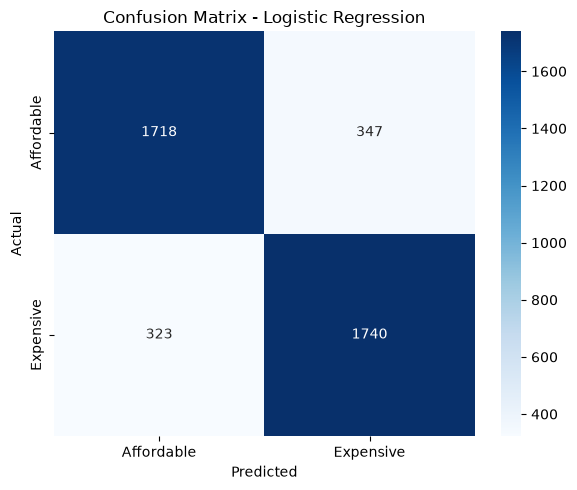

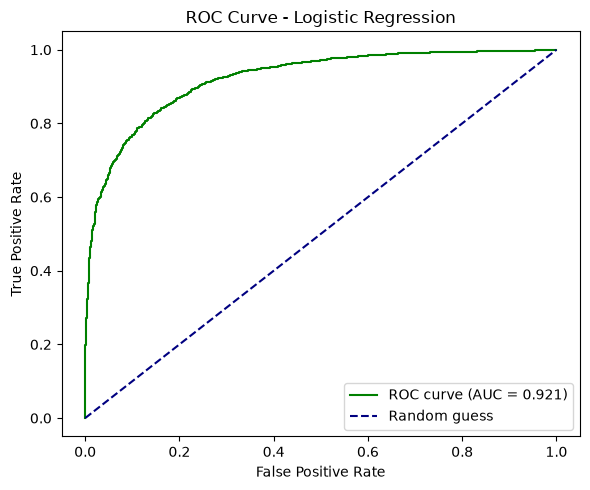

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# ---------------------------------------------------
# STEP 1: Load Data
# ---------------------------------------------------
df = pd.read_csv('housing 1.csv')   # update path/filename as needed

# Handle missing values (California housing has some NaNs in total_bedrooms)
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# One-hot encode the categorical column
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# ---------------------------------------------------
# STEP 2: Create binary target (logistic regression needs classes,
# not a continuous price) — split at the median
# ---------------------------------------------------
median_price = df['median_house_value'].median()
df['PriceCategory'] = (df['median_house_value'] > median_price).astype(int)  # 1 = expensive, 0 = affordable

X = df.drop(columns=['median_house_value', 'PriceCategory'])
y = df['PriceCategory']

# 
# STEP 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 4: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 5: Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# STEP 6: Predict
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# STEP 7: Evaluation

print("Intercept:", model.intercept_[0])
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)
print("\nCoefficients (standardized):\n", coef_df.to_string(index=False))

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# STEP 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Affordable', 'Expensive'],
            yticklabels=['Affordable', 'Expensive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()


# STEP 9: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='green', label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()




In [2]:
pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
